# Vol 19 — Inverse Problems & Arbitrage-Aware Surfaces

**問い:** 同じrepricing誤差でも識別性・無裁定・variance termは一致するか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

Heston/COS、SABR/Hagan、rBergomi MCの数値teacherを共通schemaへ置き、multi-start forward calibrationを主経路、direct inverseをablationとする。SSVIとconvex call projectionでhard constraintsを検査する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'surfaces.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 19
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=19 digest=005a7300a254a73b arrays=32


In [2]:
data.update({
    'strike': data['constraint_strikes'],
    'clean_teacher_price': data['constraint_clean_teacher_price'],
    'hard_constrained_price': data['constraint_hard_price'],
    'start_index': np.arange(len(data['calibration_start_repricing_rmse'])),
    'start_parameter_rmse': np.sqrt(np.mean((data['calibration_start_parameters'] - data['calibration_truth'][None, :]) ** 2, axis=1)),
    'start_repricing_rmse': data['calibration_start_repricing_rmse'],
    'pareto_lambda': data['pareto_lambdas'],
    'pareto_iv_rmse': np.sqrt(np.maximum(data['pareto_losses'][:, 1], 0.0)),
    'pareto_variance_rmse': np.sqrt(np.maximum(data['pareto_losses'][:, 2], 0.0)),
    'variance_maturity': data['teacher_maturities'],
    'target_variance': data['pareto_target_variance'],
    'iv_only_variance': data['pareto_predicted_variance'][0],
    'joint_variance': data['pareto_predicted_variance'][-1],
})

## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [3]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

array_fingerprint: sha256:4c1cd3f973efda05a09a3fb8917eff7fecf52ff09417d8cca2bee883c17936aa
array_schema: {'calibration_parameter_dispersion': {'dtype': '<f8', 'shape': [4], 'unit': 'dimensionless'}, 'calibration_parameters': {'dtype': '<f8', 'shape': [4], 'unit': 'dimensionless'}, 'calibration_start_initial': {'dtype': '<f8', 'shape': [4, 4], 'unit': 'dimensionless'}, 'calibration_start_parameters': {'dtype': '<f8', 'shape': [4, 4], 'unit': 'dimensionless'}, 'calibration_start_repricing_rmse': {'dtype': '<f8', 'shape': [4], 'unit': 'annualized_volatility'}, 'calibration_truth': {'dtype': '<f8', 'shape': [4], 'unit': 'dimensionless'}, 'constraint_clean_teacher_price': {'dtype': '<f8', 'shape': [4, 9], 'unit': 'spot_units'}, 'constraint_hard_price': {'dtype': '<f8', 'shape': [4, 9], 'unit': 'spot_units'}, 'constraint_maturities': {'dtype': '<f8', 'shape': [4], 'unit': 'years'}, 'constraint_raw_price': {'dtype': '<f8', 'shape': [4, 9], 'unit': 'spot_units'}, 'constraint_soft_price': {'dty

## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [4]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS numerical_teacher_ladder 3 Heston/COS, SABR/Hagan, and rBergomi MC on one uncertainty schema
PASS multi_start_calibration True all starts successful
PASS calibration_start_evidence 4 initial/fitted parameters, errors, evaluations, and dispersion align
PASS forward_repricing_rmse 5.2012449229271927e-11 < 1e-5
PASS hard_surface_report True complete and all checks pass
PASS raw_stress_detected False is false
PASS joint_variance_refits 3 >= 2 distinct actual refits
PASS variance_pareto_improvement 2.1682376937831574e-06 < lambda=0 variance loss
PASS direct_inverse_role ablation_only == ablation_only
PASS direct_inverse_evidence 8 aligned parameter and repricing ablation arrays
PASS pareto_evidence 3 each actual refit has losses, parameters, and nondominance status


## clean teacher価格とhard-constrained fit

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


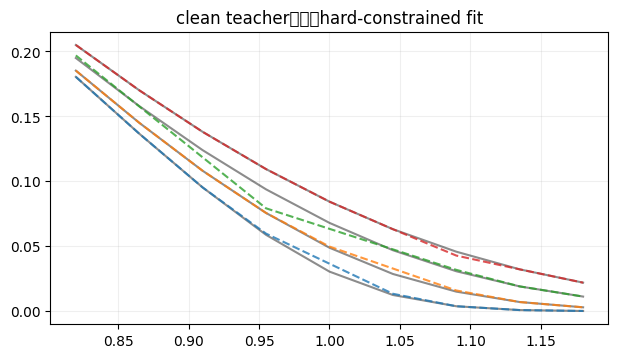

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("clean teacher価格とhard-constrained fit")
for i in range(data["clean_teacher_price"].shape[0]):
    ax.plot(data["strike"], data["clean_teacher_price"][i], color="black", alpha=.45)
    ax.plot(data["strike"], data["hard_constrained_price"][i], linestyle="--", alpha=.8)
ax.grid(alpha=.2)
plt.show()

## multi-start parameter/repricing RMSE

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

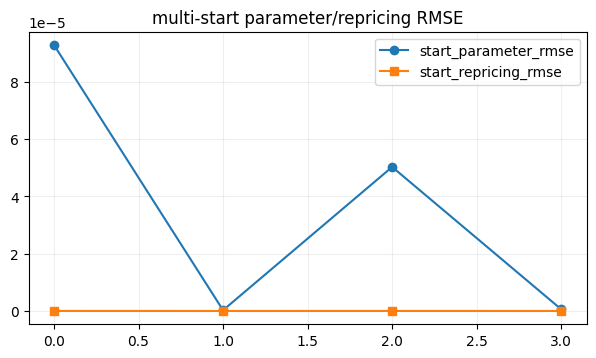

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("multi-start parameter/repricing RMSE")
ax.plot(data["start_index"], data["start_parameter_rmse"], marker="o", label="start_parameter_rmse")
ax.plot(data["start_index"], data["start_repricing_rmse"], marker="s", label="start_repricing_rmse")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## IV fitとvariance termのPareto frontier

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


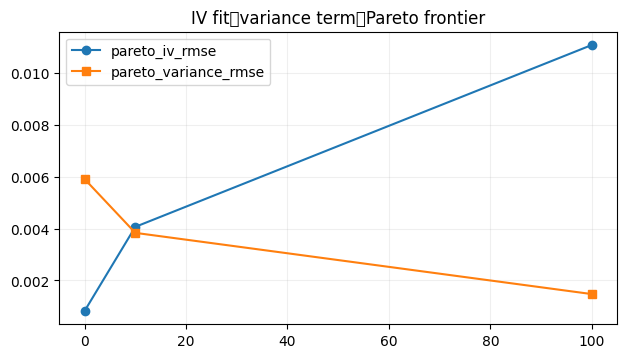

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("IV fitとvariance termのPareto frontier")
ax.plot(data["pareto_lambda"], data["pareto_iv_rmse"], marker="o", label="pareto_iv_rmse")
ax.plot(data["pareto_lambda"], data["pareto_variance_rmse"], marker="s", label="pareto_variance_rmse")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## variance term consistency

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

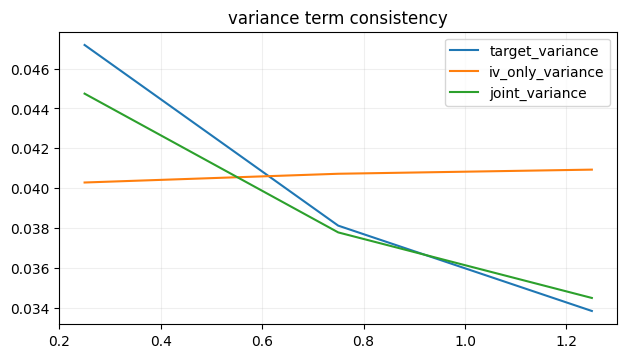

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("variance term consistency")
ax.plot(data["variance_maturity"], data["target_variance"], label="target_variance")
ax.plot(data["variance_maturity"], data["iv_only_variance"], label="iv_only_variance")
ax.plot(data["variance_maturity"], data["joint_variance"], label="joint_variance")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [9]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Gatheral & Jacquier (2014), Arbitrage-free SVI volatility surfaces; Heston (1993).

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。